<a href="https://colab.research.google.com/github/csataridominik/ML_Projects/blob/main/Finance%20and%20Economics/stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

In [31]:
df = pd.read_csv('https://raw.githubusercontent.com/gopikrsmscs/stock-price-prediction-lstm/refs/heads/main/TSLA.csv')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [32]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


In [34]:
df.shape

(2956, 7)

<Axes: >

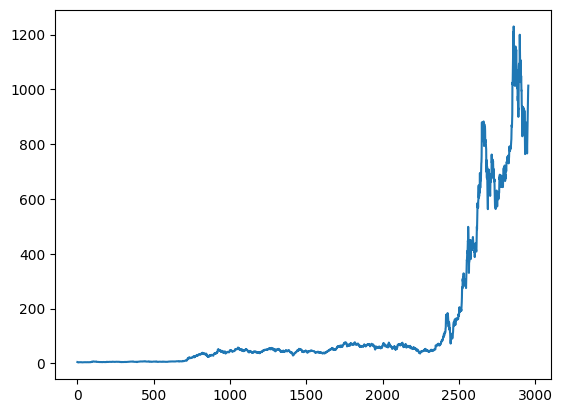

In [35]:
df['Close'].plot()

In [36]:
sum(df['Close'] == df['Adj Close'])

2956

In [37]:
df = df.drop(['Adj Close'], axis=1)

In [38]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [39]:
df.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


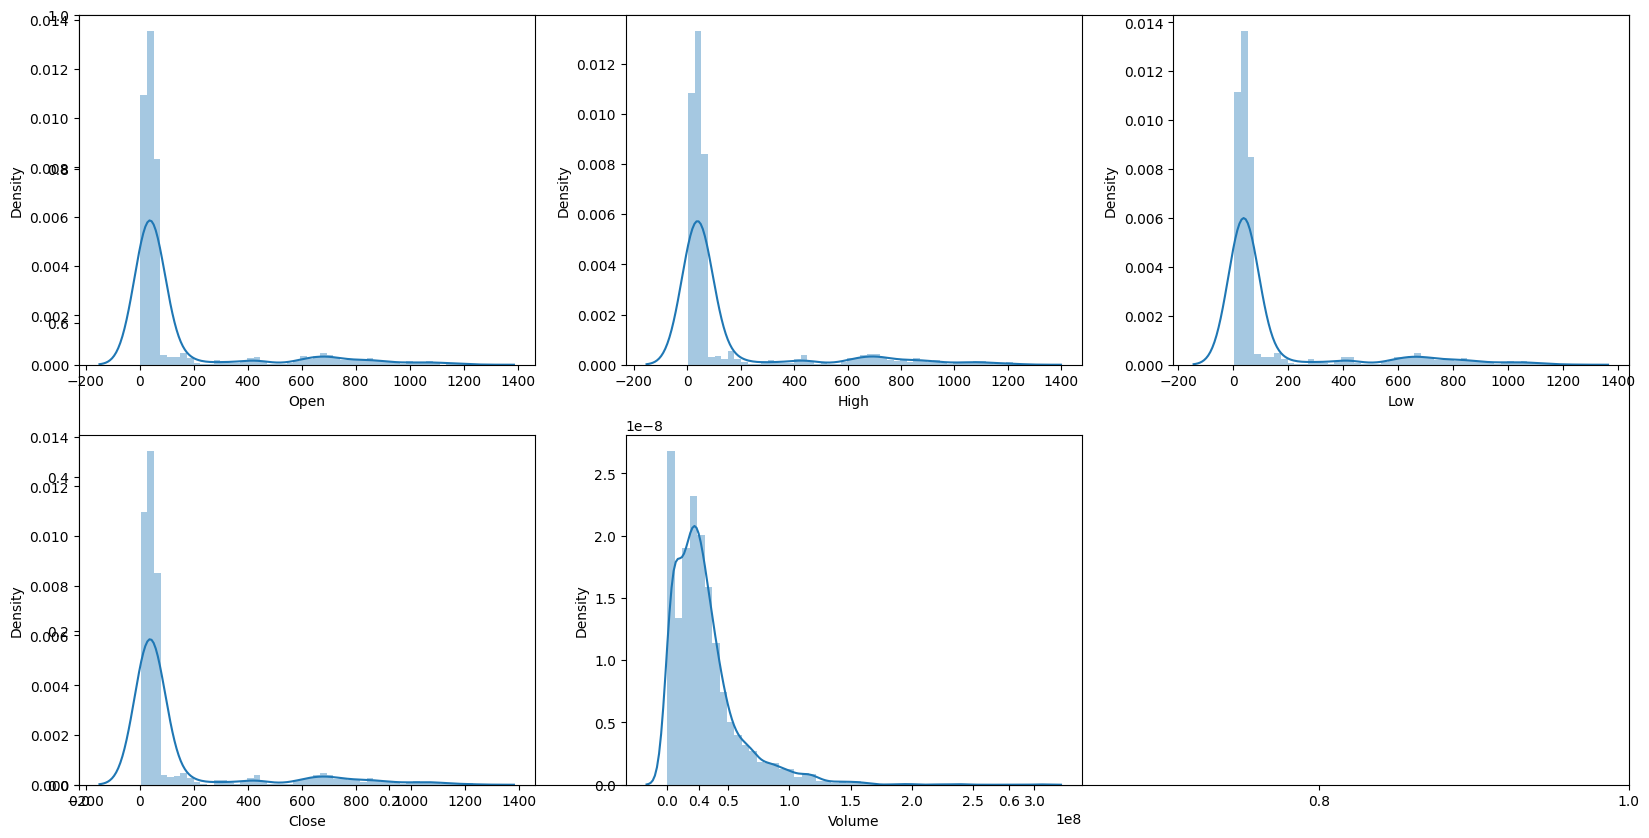

In [40]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.distplot(df[col])
plt.show()

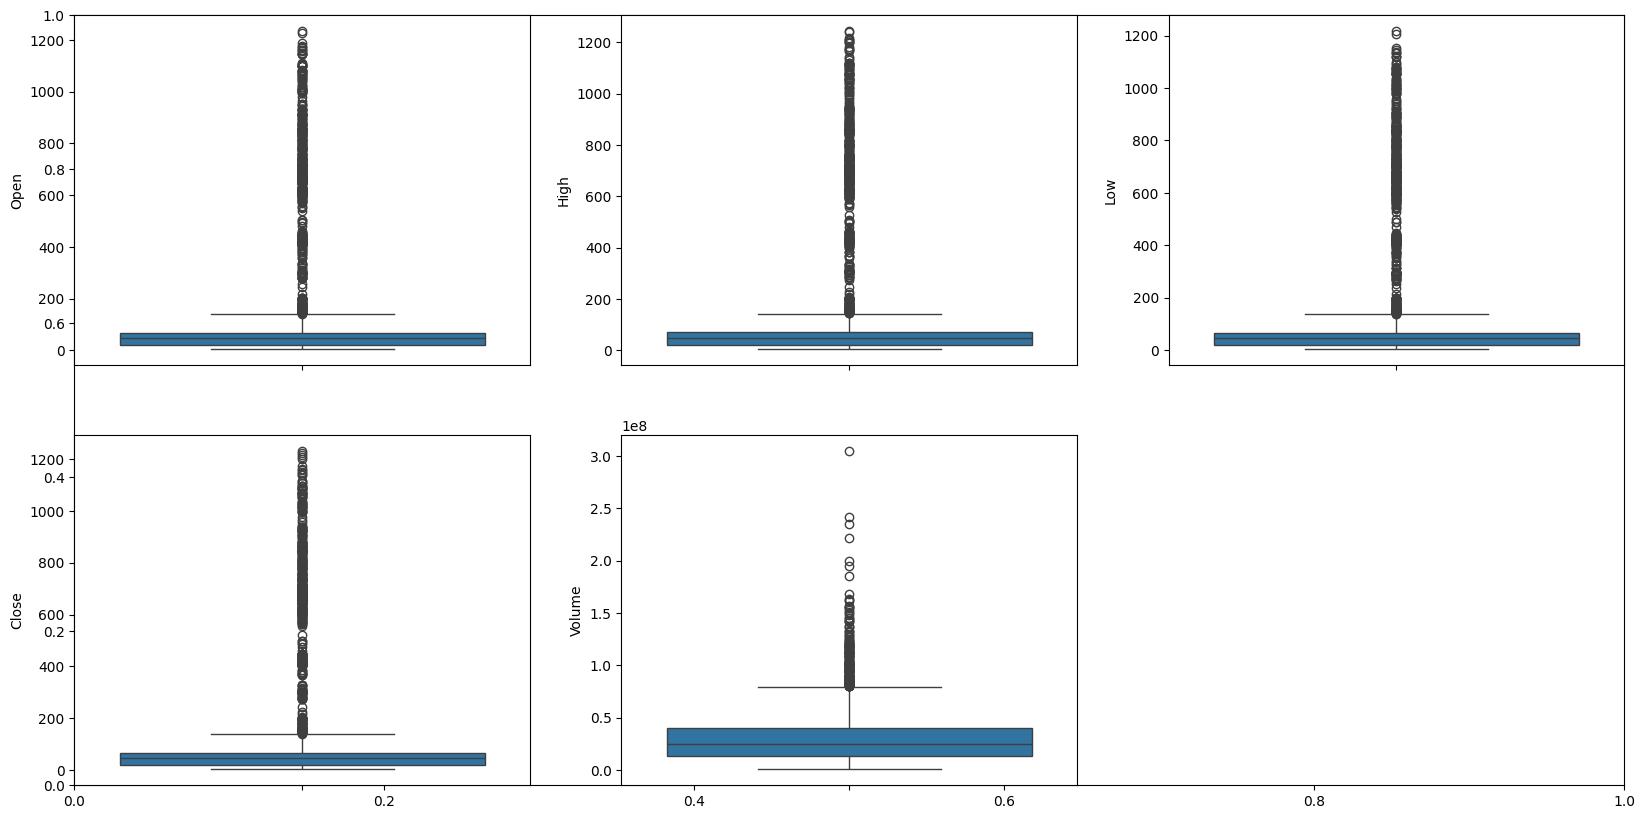

In [41]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sns.boxplot(df[col])
plt.show()

In [42]:
splitted = df['Date'].str.split('-',expand=True)

df['month'] = splitted[1].astype('int')
df['year'] = splitted[0].astype('int')
df['day'] = splitted[2].astype('int')

df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head()


,Date,Open,High,Low,Close,Volume,month,year,day,is_quarter_end
0,2010-06-29,3.800,5.000,3.508,4.778,93831500,6,2010,29,1
1,2010-06-30,5.158,6.084,4.660,4.766,85935500,6,2010,30,1
2,2010-07-01,5.000,5.184,4.054,4.392,41094000,7,2010,1,0
3,2010-07-02,4.600,4.620,3.742,3.840,25699000,7,2010,2,0
4,2010-07-06,4.000,4.000,3.166,3.222,34334500,7,2010,6,0


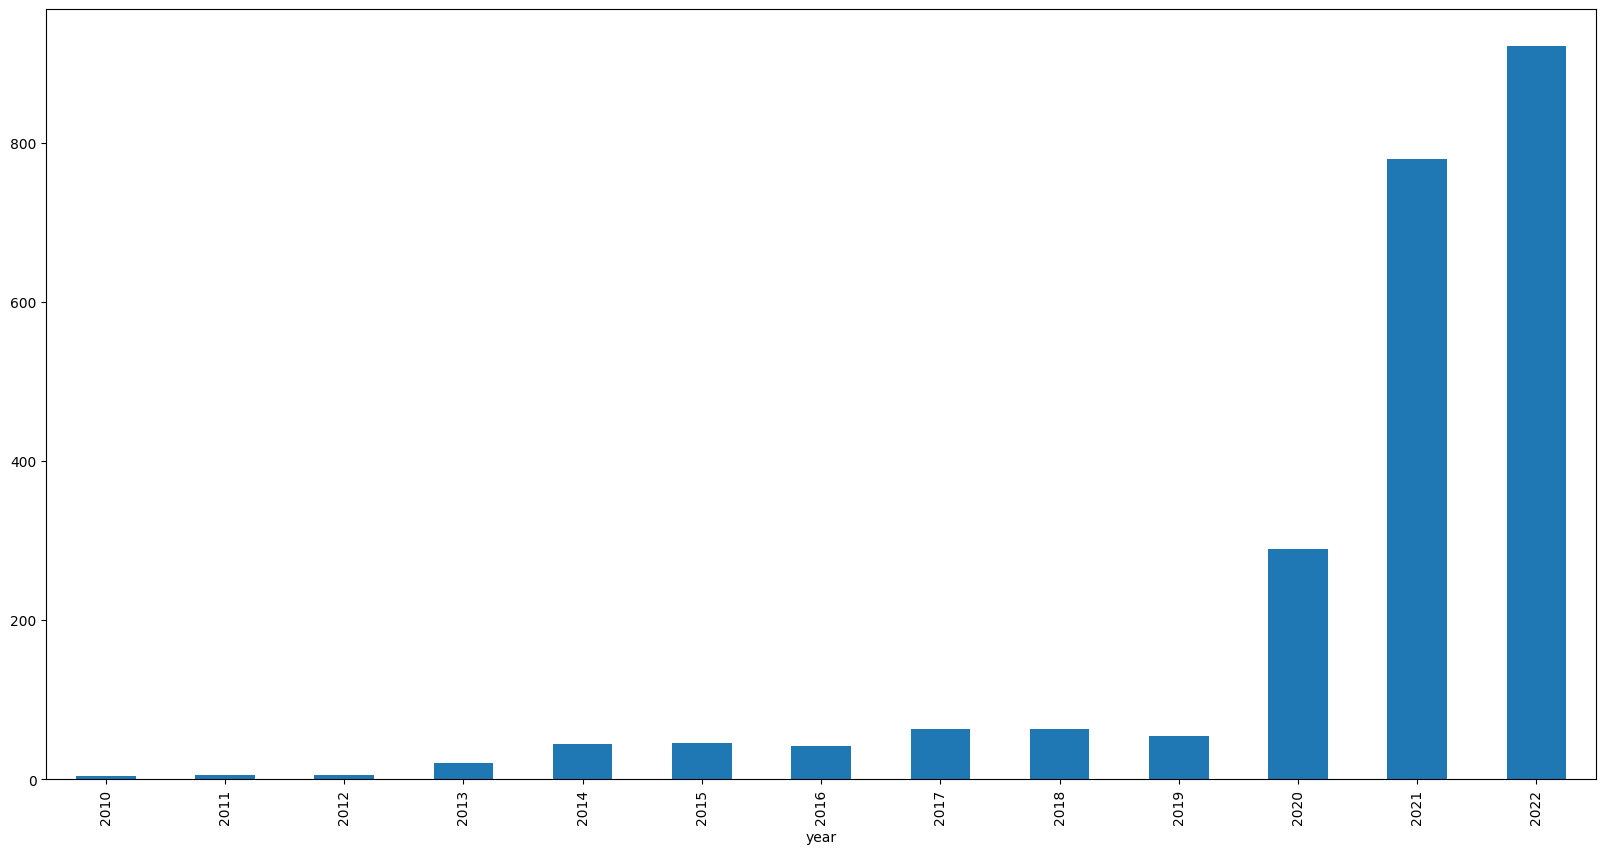

In [43]:
data_grouped = df[['Close','year']].groupby('year').mean()
plt.subplots(figsize=(20,10))

data_grouped['Close'].plot.bar()
plt.show()

# This code is modified by Susobhan Akhuli

In [44]:
df['year'].nunique()

13

In [45]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

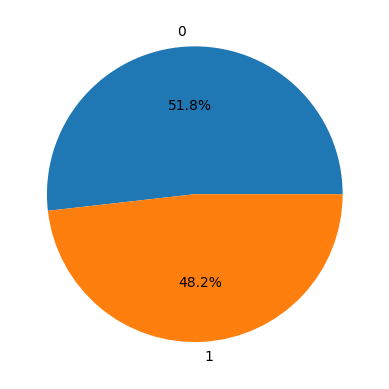

In [46]:
plt.pie(df['target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

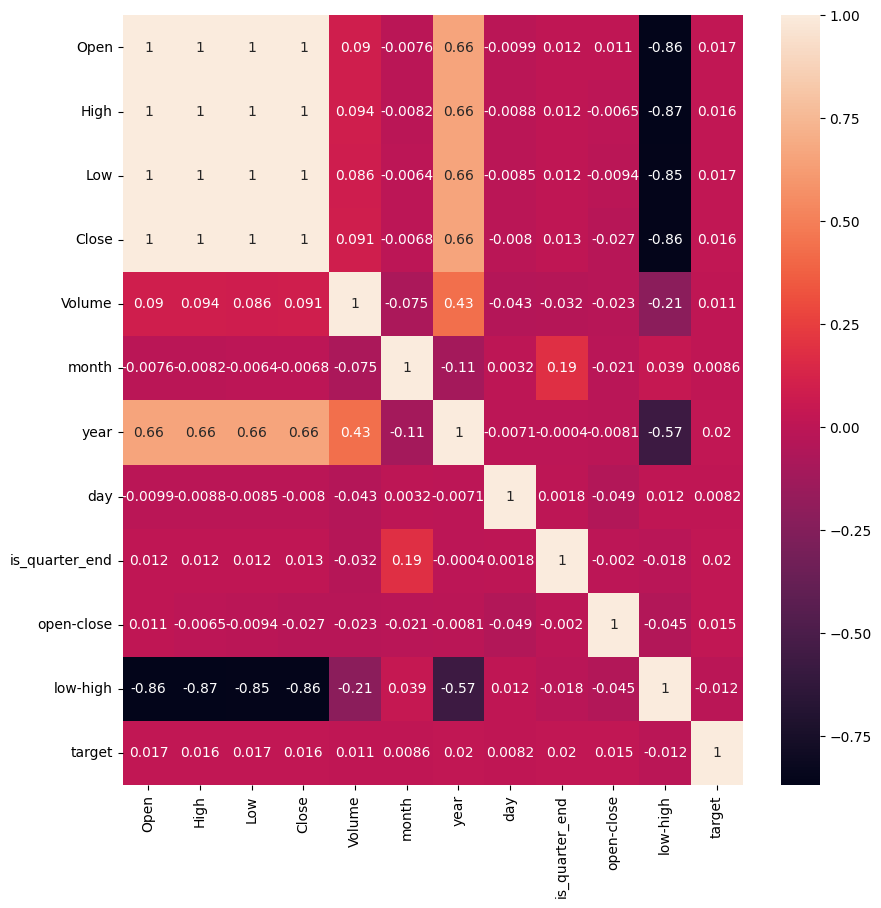

In [55]:
plt.figure(figsize=(10, 10))

sns.heatmap(df.drop('Date', axis=1).corr(),annot=df.drop('Date', axis=1).corr(), cbar=True)
plt.show()


In [57]:
features = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    features, target, test_size=0.1, random_state=42)
print(X_train.shape, X_valid.shape)

(2660, 3) (296, 3)


Train

In [58]:
models = [LogisticRegression(), SVC(
  kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.5180273081004598
Validation Accuracy :  0.49908424908424914

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.49866600636717373
Validation Accuracy :  0.47445054945054943

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Tra

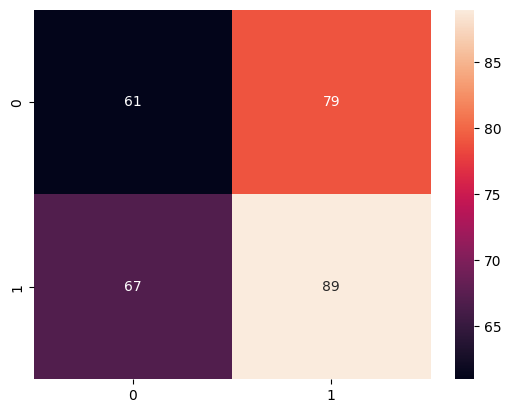

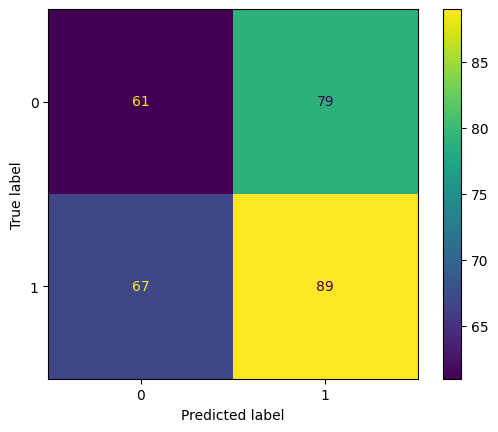

In [80]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = np.round(models[2].predict_proba(X_valid)[:,1])

sns.heatmap(confusion_matrix(Y_valid, y_pred),annot=True)
ConfusionMatrixDisplay.from_estimator(models[2], X_valid, Y_valid)
plt.show()